In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
TRAIN_DIR = Path("../dataset/train")
VALIDATION_DIR = Path("../dataset/validation")
TEST_DIR = Path("../dataset/test")

CLASSES = ["Cr", "In", "Pa", "PS", "RS", "Sc"]

print("Dataset paths configured successfully")

Dataset paths configured successfully


In [3]:
for split_name, split_dir in [
    ("Train", TRAIN_DIR),
    ("Validation", VALIDATION_DIR),
    ("Test", TEST_DIR)
]:
    
    print(f"\n{split_name}")
    print("-" * 30)
    
    for class_name in CLASSES:
        
        class_dir = split_dir / class_name
        
        count = len(list(class_dir.glob("*.bmp")))
        
        print(f"{class_name}: {count}")


Train
------------------------------
Cr: 210
In: 210
Pa: 210
PS: 210
RS: 210
Sc: 210

Validation
------------------------------
Cr: 45
In: 45
Pa: 45
PS: 45
RS: 45
Sc: 45

Test
------------------------------
Cr: 45
In: 45
Pa: 45
PS: 45
RS: 45
Sc: 45


In [4]:
class_names = {
    "Cr": "Crazing",
    "In": "Inclusion",
    "Pa": "Patches",
    "PS": "Pitted Surface",
    "RS": "Rolled-in Scale",
    "Sc": "Scratches"
}

for code, name in class_names.items():
    print(f"{code} → {name}")

Cr → Crazing
In → Inclusion
Pa → Patches
PS → Pitted Surface
RS → Rolled-in Scale
Sc → Scratches


In [5]:
sample_image = TRAIN_DIR / "Cr" / "Cr_1.bmp"

image = Image.open(sample_image)

print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (200, 200)
Image mode: L


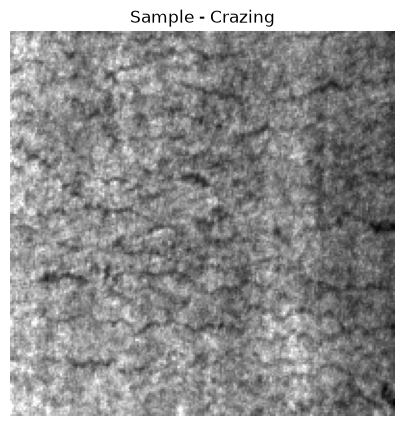

In [6]:
plt.figure(figsize=(5, 5))

plt.imshow(image, cmap="gray")

plt.title("Sample - Crazing")

plt.axis("off")

plt.show()

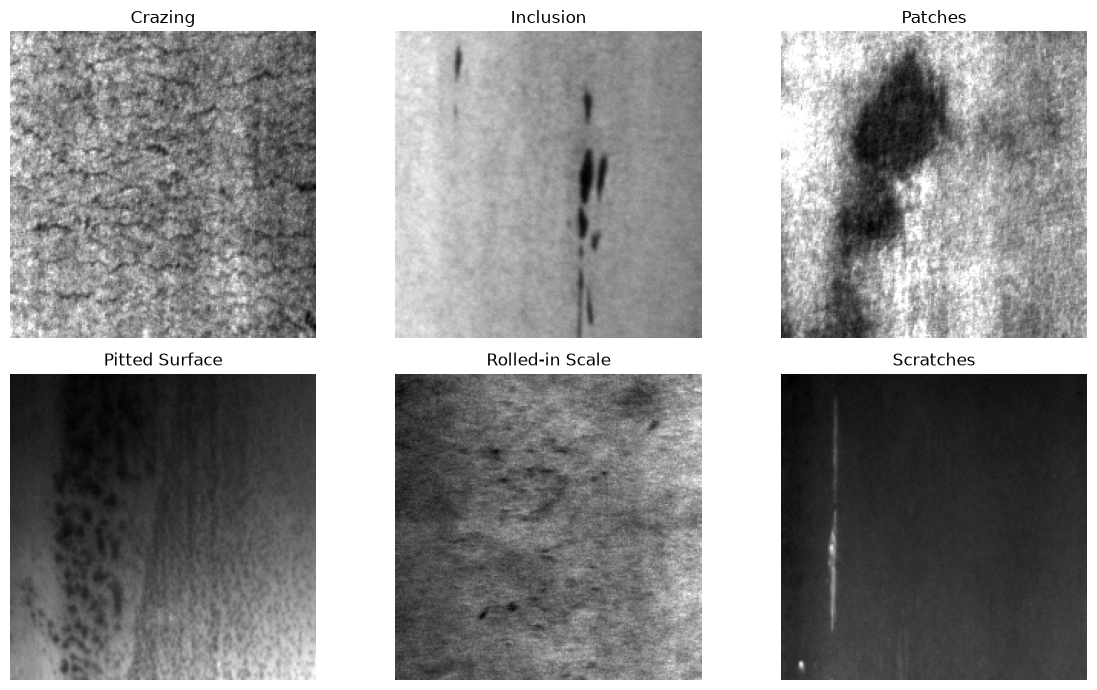

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, class_name in zip(axes.ravel(), CLASSES):
    
    class_dir = TRAIN_DIR / class_name
    
    image_path = next(class_dir.glob("*.bmp"))
    
    image = Image.open(image_path)
    
    ax.imshow(image, cmap="gray")
    
    ax.set_title(class_names[class_name])
    
    ax.axis("off")

plt.tight_layout()
plt.show()

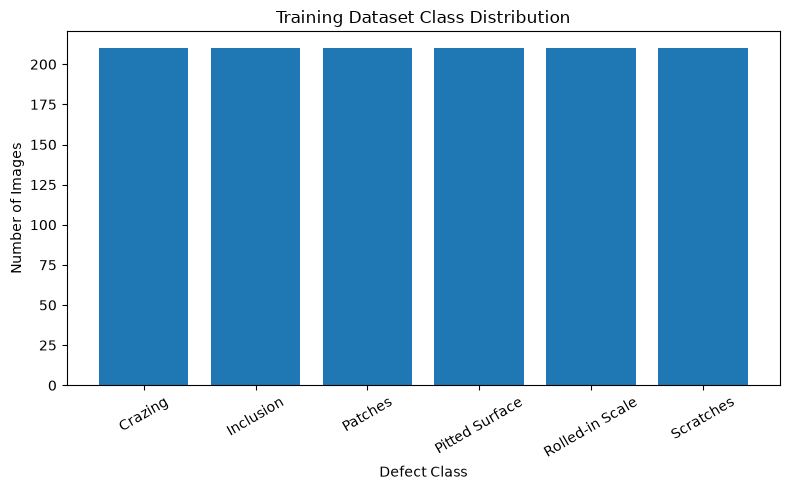

In [8]:
train_counts = []

for class_name in CLASSES:
    
    class_dir = TRAIN_DIR / class_name
    
    count = len(list(class_dir.glob("*.bmp")))
    
    train_counts.append(count)

plt.figure(figsize=(8, 5))

plt.bar(
    [class_names[c] for c in CLASSES],
    train_counts
)

plt.xlabel("Defect Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [9]:
def check_images(directory):
    
    corrupted = []
    
    for image_path in directory.rglob("*.bmp"):
        
        try:
            with Image.open(image_path) as img:
                img.verify()
                
        except Exception:
            corrupted.append(image_path)
    
    return corrupted

In [10]:
corrupted_train = check_images(TRAIN_DIR)
corrupted_validation = check_images(VALIDATION_DIR)
corrupted_test = check_images(TEST_DIR)

print("Corrupted training images:", len(corrupted_train))
print("Corrupted validation images:", len(corrupted_validation))
print("Corrupted test images:", len(corrupted_test))

Corrupted training images: 0
Corrupted validation images: 0
Corrupted test images: 0


In [ ]:
from torchvision import transforms
from PIL import Image

image_path = TRAIN_DIR / "Cr" / "Cr_1.bmp"

image = Image.open(image_path)

print("Original size:", image.size)
print("Original mode:", image.mode)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

tensor_image = transform(image)

print("Tensor shape:", tensor_image.shape)
print("Tensor type:", tensor_image.dtype)


In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from torchvision import transforms
from PIL import Image

image_path = TRAIN_DIR / "Cr" / "Cr_1.bmp"

image = Image.open(image_path)

print("Original size:", image.size)
print("Original mode:", image.mode)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

tensor_image = transform(image)

print("Tensor shape:", tensor_image.shape)
print("Tensor type:", tensor_image.dtype)